In [1]:
import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
X_PCA_PATH = "/kaggle/input/gene-preprocess/saved_model/X_pca.npy"

OUTPUT_DIR = "/kaggle/working/"
OUTPUT_DIR_MODEL = os.path.join(OUTPUT_DIR, "agg_results")
os.makedirs(OUTPUT_DIR_MODEL, exist_ok=True)

OUTPUT_DIR_ENSEMBLE = os.path.join(OUTPUT_DIR, "agg_ensemble")
os.makedirs(OUTPUT_DIR_ENSEMBLE, exist_ok=True)

In [3]:
X_pca = np.load(X_PCA_PATH)
print("X_pca shape:", X_pca.shape)

X_pca shape: (111, 10)


In [4]:
k_range = range(2, 20)

results = {
    'k': [],
    'silhouette': [],
    'labels': []
}

for k in k_range:
    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage="average",
        metric="euclidean"
    )
    
    labels = agg.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    
    results['k'].append(k)
    results['silhouette'].append(score)
    results['labels'].append(labels)
    
    print(f"k={k} | silhouette={score}")

k=2 | silhouette=0.4339821268633138
k=3 | silhouette=0.38355549036180336
k=4 | silhouette=0.3767624309081082
k=5 | silhouette=0.3424832472172213
k=6 | silhouette=0.30973064971914427
k=7 | silhouette=0.30828452423611963
k=8 | silhouette=0.276776338897658
k=9 | silhouette=0.2775681925429638
k=10 | silhouette=0.2727544259881435
k=11 | silhouette=0.26613866634955724
k=12 | silhouette=0.26188514726186046
k=13 | silhouette=0.25033764177544043
k=14 | silhouette=0.29802571226632046
k=15 | silhouette=0.3065586909473898
k=16 | silhouette=0.3095588275755027
k=17 | silhouette=0.31835696870836694
k=18 | silhouette=0.3197765755733749
k=19 | silhouette=0.3245911612932789


In [5]:
df_results = pd.DataFrame(results)
df_results.head()

,k,silhouette,labels
0,2,0.433982,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,3,0.383555,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,4,0.376762,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,5,0.342483,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,6,0.309731,"[2, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 2, 2, 2, 2, ..."


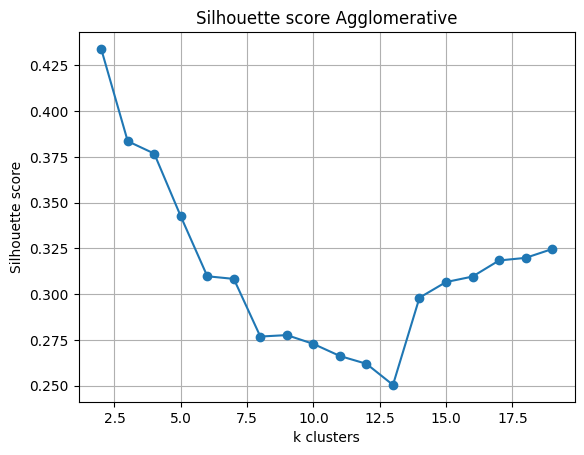

In [6]:
plt.plot(df_results["k"], df_results["silhouette"], marker="o")
plt.xlabel("k clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette score Agglomerative")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR_MODEL, "agg_silhouette.png"))
plt.show()

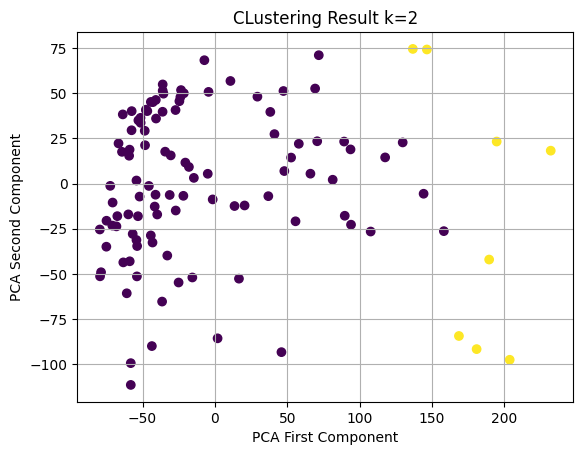

In [7]:
k = 2
row_index = k-2
df_label = df_results['labels'][row_index]

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_label)
plt.xlabel("PCA First Component")
plt.ylabel("PCA Second Component")
plt.title(f"CLustering Result k={k}")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR_MODEL, "agg_clustering.png"))
plt.show()

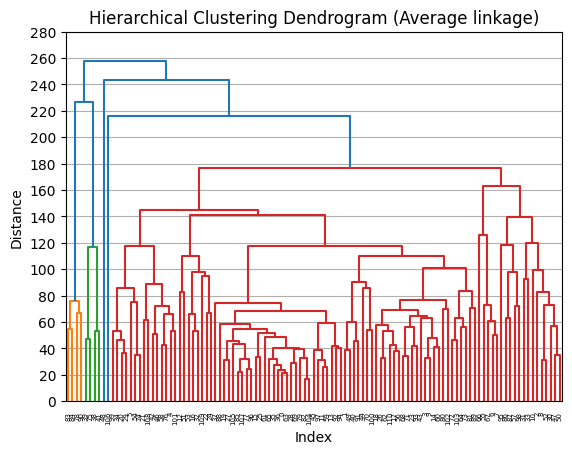

In [8]:
Z = linkage(X_pca, method="average", metric="euclidean")

dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Average linkage)")
plt.xlabel("Index")
plt.ylabel("Distance")
plt.yticks(np.arange(0, 300, step=20))
plt.grid(axis="y")
plt.savefig(os.path.join(OUTPUT_DIR_ENSEMBLE, "agg_ensemble_dendrogram.png"))
plt.show()

In [9]:
labels_agg = fcluster(Z, t=200, criterion='distance')
print(silhouette_score(X_pca, labels_agg))
len(np.unique(labels_agg))

0.3424832472172213


5

In [10]:
path = os.path.join(OUTPUT_DIR_MODEL, "agg_all_results.csv")
df_results.to_csv(path, index=False)

path = os.path.join(OUTPUT_DIR_MODEL, "agg_config.json")
config = {
    'k': 2,
    'method': "average",
    'metric': "euclidean"
}
with open(path, "w") as f:
    json.dump(config, f)

path = os.path.join(OUTPUT_DIR_MODEL, "agg_labels.npy")
np.save(path, df_results['labels'][row_index])

In [11]:
path = os.path.join(OUTPUT_DIR_ENSEMBLE, "agg_ensemble_labels.npy")
np.save(path, labels_agg)

path = os.path.join(OUTPUT_DIR_ENSEMBLE, "agg_ensemble_config.npy")
config = {
    'k': 5,
    'method': "average",
    'metric': "euclidean"
}
with open(path, "w") as f:
    json.dump(config, f)